# Machine learning

---

In [2]:
import pandas as pd
df = pd.read_csv("box_model_output.csv")

from datetime import datetime, timezone
import numpy as np
from pytz import timezone
df["UTC_Start_dt"] = pd.to_datetime(df["UTC_Start_dt"])
df['date'] = df['UTC_Start_dt']

## Machine learning

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

df_inputs = df[['Temp', 'Pres', 'jO3_O2_O1D_CAFS', 'O3_M', 'H2O_M', 'CO_M', 'CH4_M']]
df_inputs_HO2 = df[['Temp', 'Pres', 'jO3_O2_O1D_CAFS', 'O3_M', 'H2O_M', 'CO_M', 'CH4_M', 'HO2_ATHOS']]

# Example data
X = df_inputs   # 100 samples, 5 input features
X_HO2 = df_inputs_HO2
y = df["[OH]_measured"]  # single output

X_train = df_inputs[df["date"] < "2016-08-22"]
X_train_normalised = scaler.fit_transform(X_train)

X_train_HO2 = df_inputs_HO2[df["date"] < "2016-08-22"]
X_train_normalised_HO2 = scaler.fit_transform(X_train_HO2)

y_train = df[["[OH]_measured"]][df["date"] < "2016-08-22"]
y_train_normalised = scaler.fit_transform(y_train)

X_test = df_inputs[(df["date"] > "2016-08-22")]
X_test_normalised = scaler.fit_transform(X_test)

X_test_HO2 = df_inputs_HO2[(df["date"] > "2016-08-22")]
X_test_normalised_HO2 = scaler.fit_transform(X_test_HO2)

y_test = df[["[OH]_measured"]][(df["date"] > "2016-08-22")]

### Linear regression
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

LinearRegression fits a linear model with coefficients w = (w1, …, wp) to minimize the residual sum of squares between the observed targets in the dataset, and the targets predicted by the linear approximation.

In [5]:
indexes = df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")].count()
df["date"][0:indexes]
X_test[indexes:]

,Temp,Pres,jO3_O2_O1D_CAFS,O3_M,H2O_M,CO_M,CH4_M
6136,293.613,852.271,0.000017,5.014060e-08,0.013639,1.116052e-07,0.000002
6137,289.271,795.895,0.000018,4.988970e-08,0.014180,1.183961e-07,0.000002
6138,288.145,781.915,0.000020,5.205770e-08,0.014616,1.213163e-07,0.000002
6139,287.611,774.403,0.000020,5.203800e-08,0.014441,1.211266e-07,0.000002
6140,286.931,746.009,0.000020,5.323800e-08,0.007691,1.210388e-07,0.000002
...,...,...,...,...,...,...,...
6545,287.376,734.283,0.000048,5.419620e-08,0.007266,1.485790e-07,0.000002
6546,288.683,749.875,0.000047,5.082710e-08,0.007460,1.320212e-07,0.000002
6547,290.545,771.085,0.000046,5.125980e-08,0.007838,1.325316e-07,0.000002
6548,291.259,777.013,0.000046,5.167830e-08,0.007777,1.355386e-07,0.000002


Model score on training data: 0.4910812910922555
Model score on testing data: 0.3423917605267457
WITH HO2
Model score on training data: 0.5726651664650941
Model score on testing data: 0.49166754599403073


Text(0.5, 1.0, 'Linear regression')

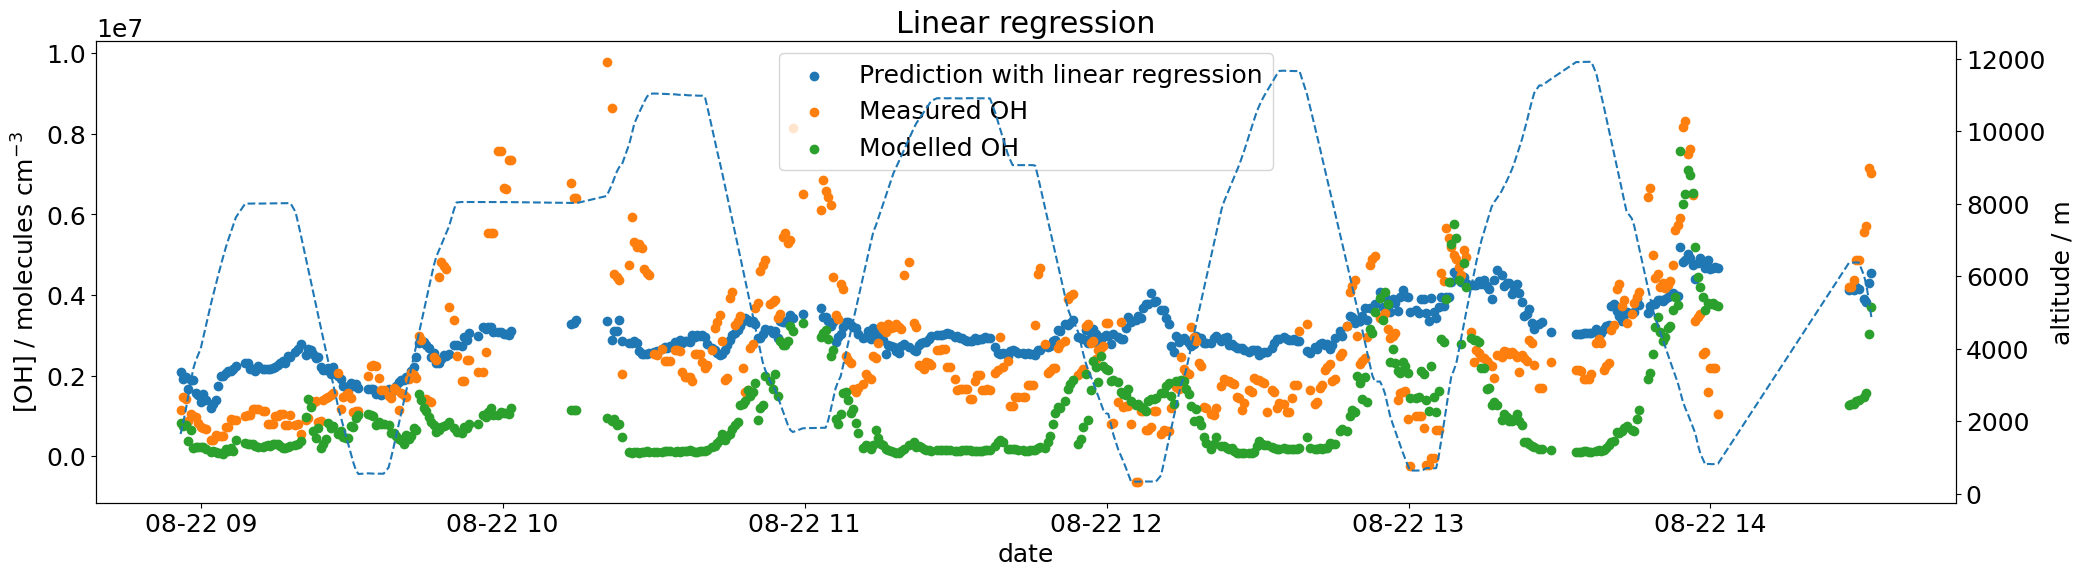

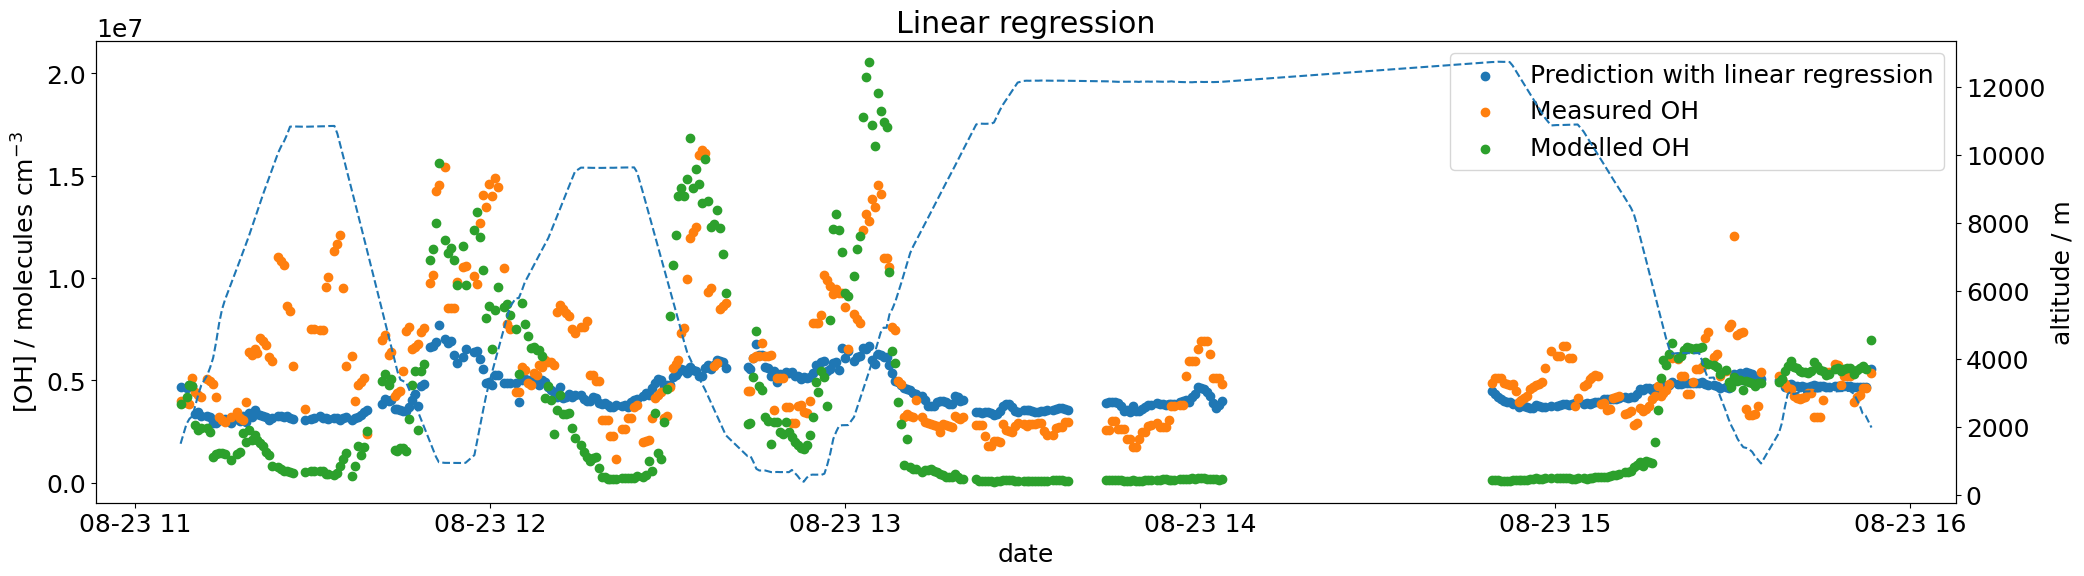

In [7]:
import matplotlib as mpl
import matplotlib.pyplot as plt
reg = LinearRegression().fit(X_train, y_train)
pred_reg = reg.predict(X_test)

reg_HO2 = LinearRegression().fit(X_train_HO2, y_train)
pred_reg_HO2 = reg_HO2.predict(X_test_HO2)

print(f"Model score on training data: {reg.score(X_train, y_train)}")
print(f"Model score on testing data: {reg.score(X_test, y_test)}")

print("WITH HO2")

print(f"Model score on training data: {reg_HO2.score(X_train_HO2, y_train)}")
print(f"Model score on testing data: {reg_HO2.score(X_test_HO2, y_test)}")


mpl.rcParams["font.size"] = 18


fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_xlabel('date')
ax1.set_ylabel('[OH] / molecules cm$^{-3}$')
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], pred_reg[0:indexes], label = "Prediction with linear regression")
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], y_test[0:indexes], label = "Measured OH")
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], df["[OH]_calc"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], label = "Modelled OH")
ax1.legend(prop={'size':20})

ax2 = ax1.twinx()
ax2.set_ylabel('altitude / m')
ax2.plot(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], df["Altitude"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], linestyle='--', label = "Altitude")
# ax2.set_ylim(0, 13000)
ax1.legend()
ax2

plt.title("Linear regression")

fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_xlabel('date')
ax1.set_ylabel('[OH] / molecules cm$^{-3}$')
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], pred_reg[indexes:], label = "Prediction with linear regression")
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], y_test[indexes:], label = "Measured OH")
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], df["[OH]_calc"][(df["date"] > "2016-08-23")], label = "Modelled OH")
ax1.legend(prop={'size':20})

ax2 = ax1.twinx()
ax2.set_ylabel('altitude / m')
ax2.plot(df["date"][(df["date"] > "2016-08-23")], df["Altitude"][(df["date"] > "2016-08-23")], linestyle='--', label = "Altitude")
# ax2.set_ylim(0, 13000)
ax1.legend()
ax2

plt.title("Linear regression")

[0, 1000, 2000, 3000, 4000, 5000, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000, 10500, 11000, 11500, 12000, 12500]


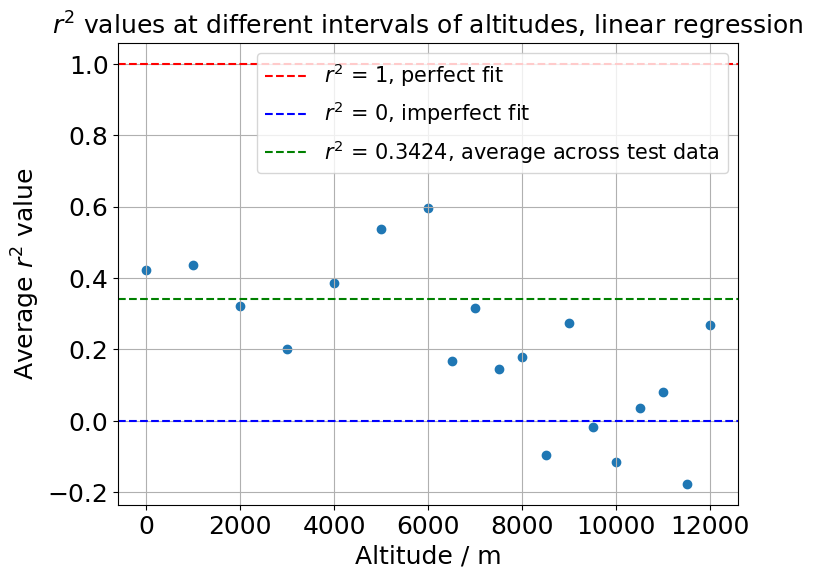

In [68]:
from sklearn.metrics import mean_squared_error
numbers = list(range(0, 6000, 1000))
numbers = numbers + (list(range(6000, 13000, 500)))
metrics_r2 = []
metrics_rmse = []
print(numbers)
for i in range(len(numbers) - 1):
    # print(numbers[i+1])
    X = X_test[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    y = y_test[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    # print("Model score for altitude:", sklearn.metrics.r2_score(X, y))
    metrics_r2.append(reg.score(X, y))
    # metrics_rmse.append(np.sqrt(mean_squared_error(X_test, y_test)))
    # print(i)

fig, ax = plt.subplots(figsize = (8, 6))
plt.rcParams.update({'font.size':15})

plt.scatter(numbers[:-1], metrics_r2)
plt.axhline(y=1, color='r', linestyle='--', label='${r^2}$ = 1, perfect fit')
plt.axhline(y=0, color='b', linestyle='--', label='${r^2}$ = 0, imperfect fit')
plt.axhline(y = (reg.score(X_test, y_test)), color = 'g', linestyle = '--', label = f'$r^2$ = {round(reg.score(X_test, y_test), 4)}, average across test data')
plt.xlabel("Altitude / m")
plt.ylabel("Average $r^2$ value")
plt.title("$r^2$ values at different intervals of altitudes, linear regression")
plt.legend(prop={'size':15})

plt.grid()

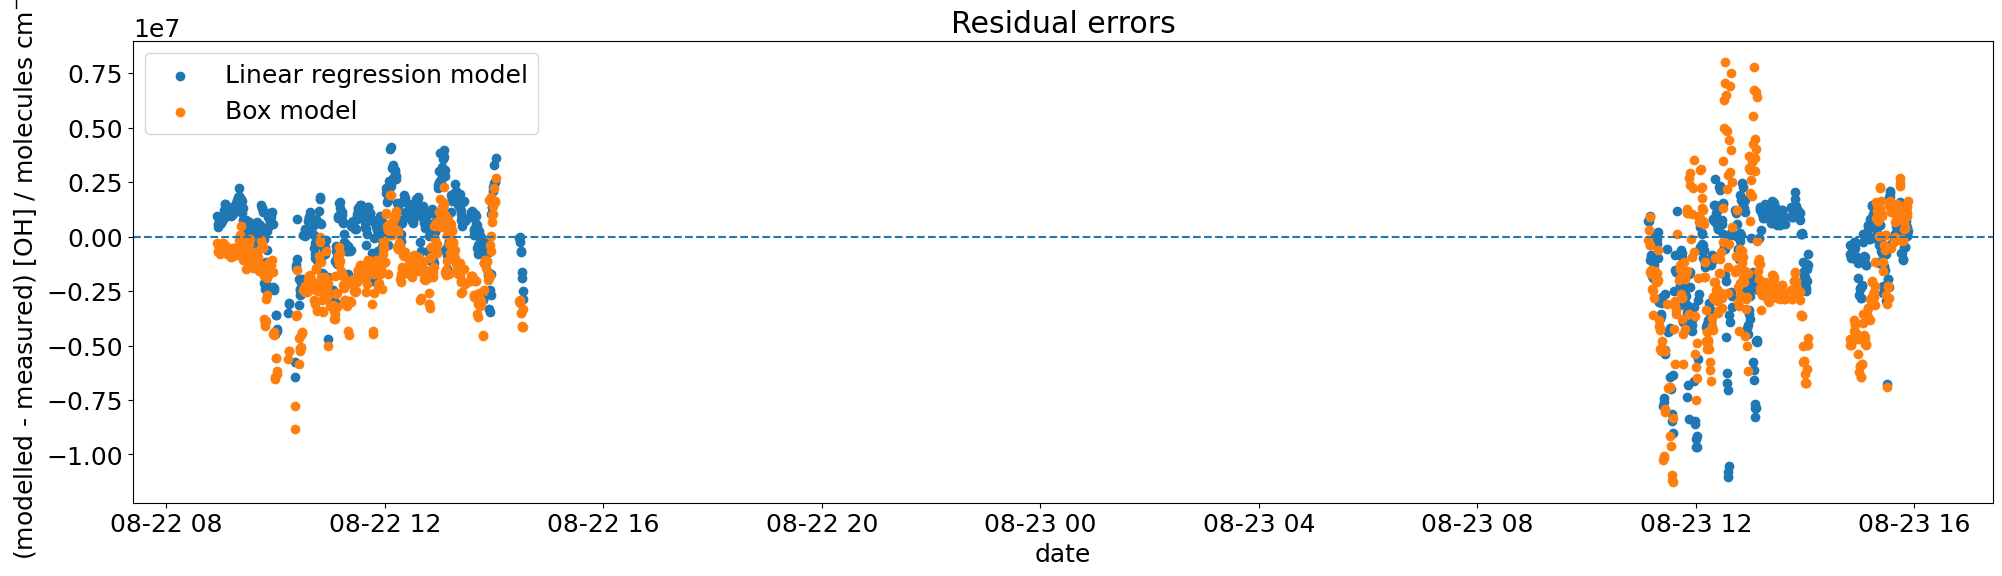

RMSE: 2267131.6568734064
RMSE with HO2: 1993274.1612247908


In [37]:
mpl.rcParams["font.size"] = 18

y_test = df[["[OH]_measured"]][(df["date"] > "2016-08-22")]

fig, ax1 = plt.subplots(figsize = (24, 6))
plt.scatter(df["date"][(df["date"] > "2016-08-22")], (reg.predict(X_test) - y_test), label='Linear regression model')

y_test = df["[OH]_measured"][(df["date"] > "2016-08-22")]

plt.scatter(df["date"][(df["date"] > "2016-08-22")], (df["[OH]_calc"][(df["date"] > "2016-08-22")] - y_test),label='Box model')


# plotting line for zero residual error
plt.axhline(y=0, linestyle = "--")

# plotting legend
plt.legend()

# plot title
plt.title("Residual errors")

plt.xlabel("date")
plt.ylabel("(modelled - measured) [OH] / molecules cm$^{-3}$")

# method call for showing the plot
plt.show()

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_reg)))
print("RMSE with HO2:", np.sqrt(mean_squared_error(y_test, pred_reg_HO2)))

### Random forest
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

A random forest is a meta estimator that fits a number of decision tree classifiers on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting.

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/sklearn/base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/sklearn/base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Model score on training data: 0.9815078522162499
Model score on testing data: 0.33032300010835525
WITH HO2
Model score on training data: 0.9794761177379993
Model score on testing data: 0.4566969321146467


Text(0.5, 1.0, 'Random forest')

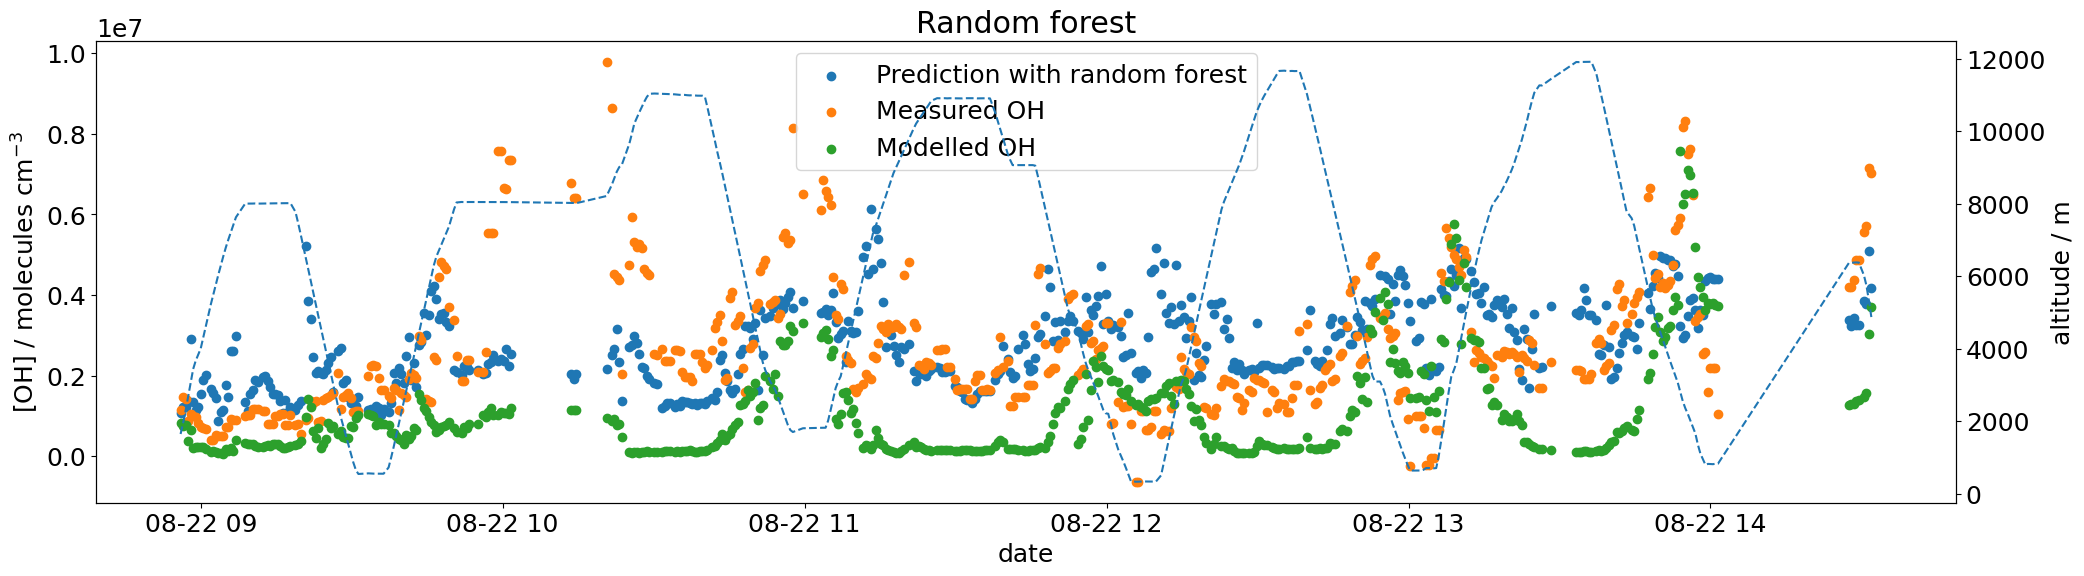

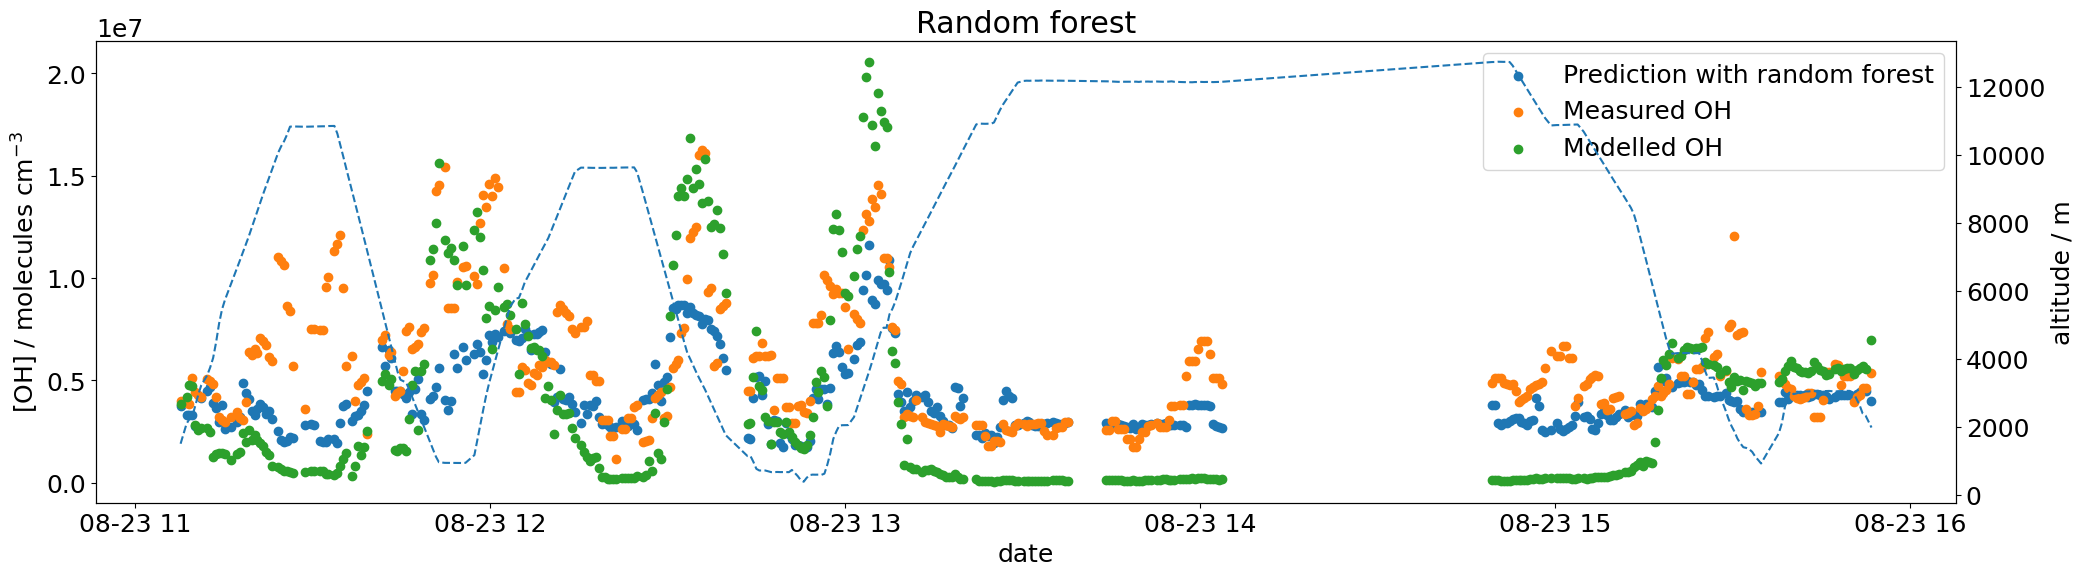

In [12]:
from sklearn.ensemble import RandomForestRegressor
rfreg = RandomForestRegressor()

rfreg.fit(X_train, y_train)

pred_rfreg = rfreg.predict(X_test)


rfreg_HO2 = RandomForestRegressor()

rfreg_HO2.fit(X_train_HO2, y_train)

pred_rfreg_HO2 = rfreg_HO2.predict(X_test_HO2)


print(f"Model score on training data: {rfreg.score(X_train, y_train)}")
print(f"Model score on testing data: {rfreg.score(X_test, y_test)}")

print("WITH HO2")

print(f"Model score on training data: {rfreg_HO2.score(X_train_HO2, y_train)}")
print(f"Model score on testing data: {rfreg_HO2.score(X_test_HO2, y_test)}")

fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_xlabel('date')
ax1.set_ylabel('[OH] / molecules cm$^{-3}$')
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], pred_rfreg[0:indexes], label = "Prediction with random forest")
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], y_test[0:indexes], label = "Measured OH")
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], df["[OH]_calc"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], label = "Modelled OH")
ax1.legend(prop={'size':20})

ax2 = ax1.twinx()
ax2.set_ylabel('altitude / m')
ax2.plot(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], df["Altitude"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], linestyle='--', label = "Altitude")
# ax2.set_ylim(0, 13000)
ax1.legend()
ax2

plt.title("Random forest")

fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_xlabel('date')
ax1.set_ylabel('[OH] / molecules cm$^{-3}$')
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], pred_rfreg[indexes:], label = "Prediction with random forest")
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], y_test[indexes:], label = "Measured OH")
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], df["[OH]_calc"][(df["date"] > "2016-08-23")], label = "Modelled OH")
ax1.legend(prop={'size':20})

ax2 = ax1.twinx()
ax2.set_ylabel('altitude / m')
ax2.plot(df["date"][(df["date"] > "2016-08-23")], df["Altitude"][(df["date"] > "2016-08-23")], linestyle='--', label = "Altitude")
# ax2.set_ylim(0, 13000)
ax1.legend()
ax2

plt.title("Random forest")

[0, 1000, 2000, 3000, 4000, 5000, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000, 10500, 11000, 11500, 12000, 12500]


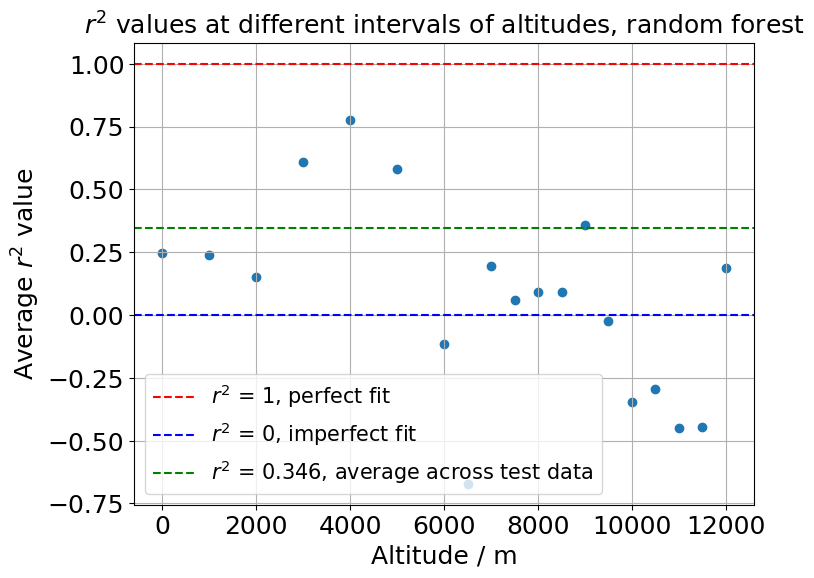

In [39]:
from sklearn.metrics import mean_squared_error
numbers = list(range(0, 6000, 1000))
numbers = numbers + (list(range(6000, 13000, 500)))
metrics_r2 = []
metrics_rmse = []
print(numbers)
for i in range(len(numbers) - 1):
    # print(numbers[i+1])
    X = X_test[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    y = y_test[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    # print("Model score for altitude:", sklearn.metrics.r2_score(X, y))
    metrics_r2.append(rfreg.score(X, y))
    # metrics_rmse.append(np.sqrt(mean_squared_error(X_test, y_test)))
    # print(i)

fig, ax = plt.subplots(figsize = (8, 6))
plt.rcParams.update({'font.size':15})

plt.scatter(numbers[:-1], metrics_r2)
plt.axhline(y=1, color='r', linestyle='--', label='${r^2}$ = 1, perfect fit')
plt.axhline(y=0, color='b', linestyle='--', label='${r^2}$ = 0, imperfect fit')
plt.axhline(y = (rfreg.score(X_test, y_test)), color = 'g', linestyle = '--', label = f'$r^2$ = {round(rfreg.score(X_test, y_test), 3)}, average across test data')
plt.xlabel("Altitude / m")
plt.ylabel("Average $r^2$ value")
plt.title("$r^2$ values at different intervals of altitudes, random forest")
plt.legend(prop={'size':15})

plt.grid()

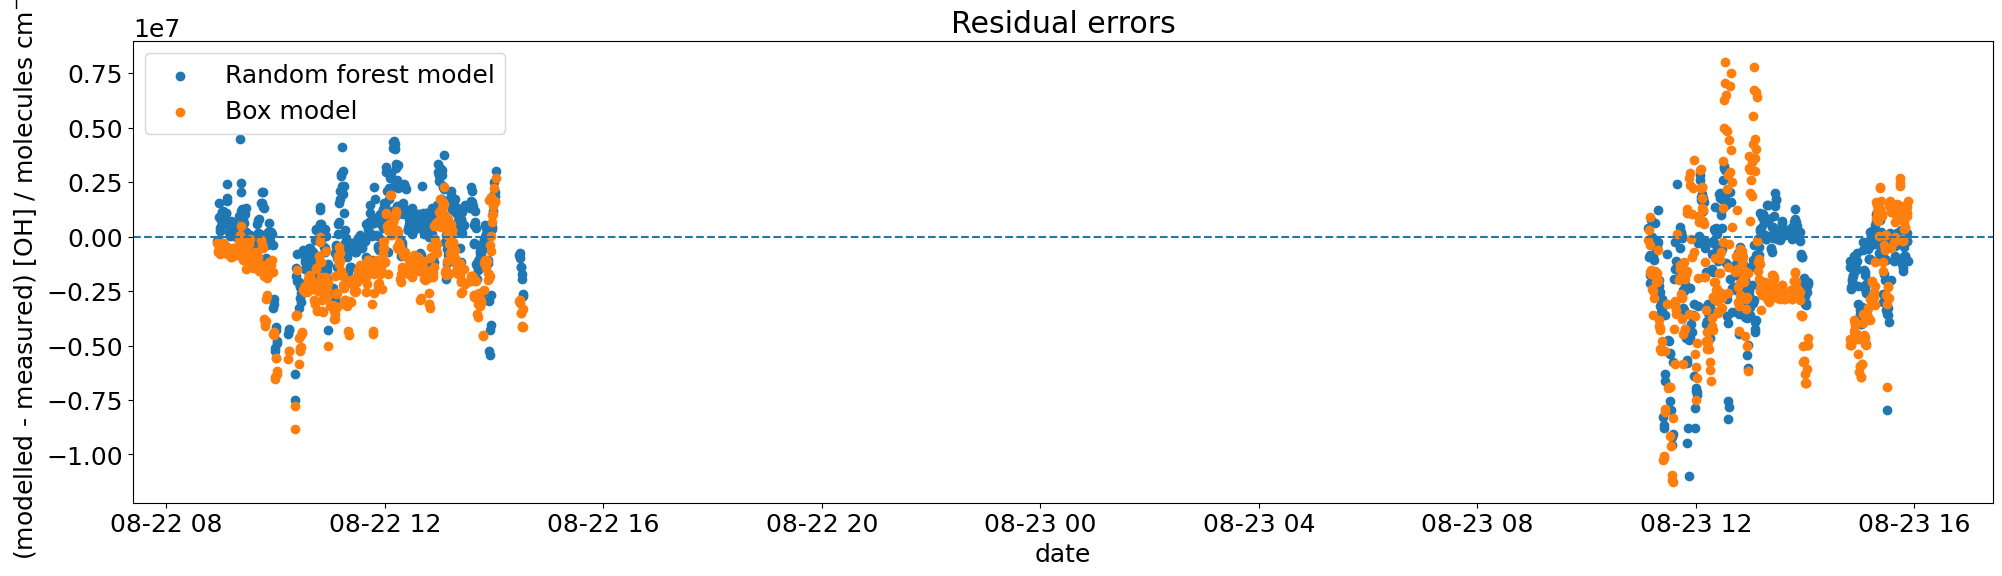

RMSE: 2260373.5048970887
RMSE with HO2: 2078811.9350833257


In [40]:
mpl.rcParams["font.size"] = 18


fig, ax1 = plt.subplots(figsize = (24, 6))
plt.scatter(df["date"][(df["date"] > "2016-08-22")], (rfreg.predict(X_test) - y_test),label='Random forest model')
plt.scatter(df["date"][(df["date"] > "2016-08-22")], (df["[OH]_calc"][(df["date"] > "2016-08-22")] - y_test),label='Box model')

# plotting line for zero residual error
plt.axhline(y=0, linestyle = "--")

# plotting legend
plt.legend()

# plot title
plt.title("Residual errors")

plt.xlabel("date")
plt.ylabel("(modelled - measured) [OH] / molecules cm$^{-3}$")

# method call for showing the plot
plt.show()

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rfreg)))
print("RMSE with HO2:", np.sqrt(mean_squared_error(y_test, pred_rfreg_HO2)))

### Feature importance with random forest

Text(0, 0.5, 'Feature')

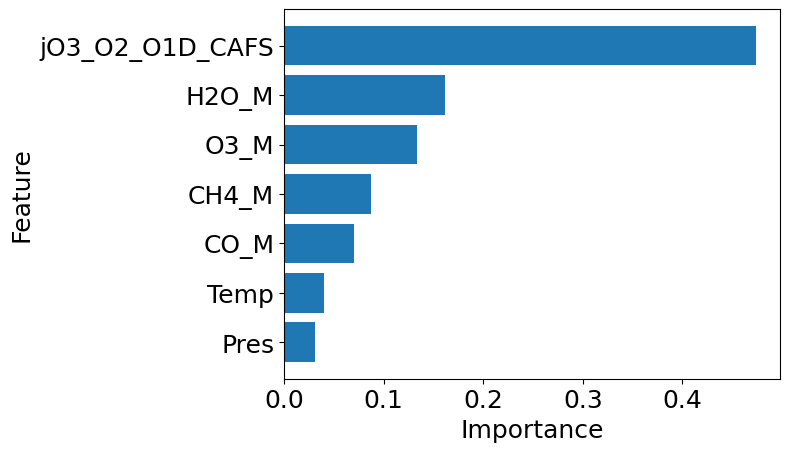

In [41]:
importances = rfreg.feature_importances_

indices = np.argsort(importances)

fig, ax = plt.subplots()
ax.barh(range(len(importances)), importances[indices])
ax.set_yticks(range(len(importances)))
_ = ax.set_yticklabels(np.array(X_train.columns)[indices])
plt.xlabel("Importance")
plt.ylabel("Feature")

Results are as expected - the production of OH depends strongly on the reaction between O(1D) and H2O and this process requires UV from sunlight.

### Ridge regression
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html

Ridge regression is an example of a regularisation procedure, which is an extension of the linear model.

This model solves a regression model where the loss function is the linear least squares function and regularization is given by the l2-norm

Used when there is collinearity in input values and ordinary least squares would overfit training data.

Model score on training data: 0.49108098424252555
Model score on testing data: 0.21396991476164973
WITH HO2
Model score on training data: 0.5726651245767047
Model score on testing data: 0.31279011971088766


Text(0.5, 1.0, 'Ridge regression')

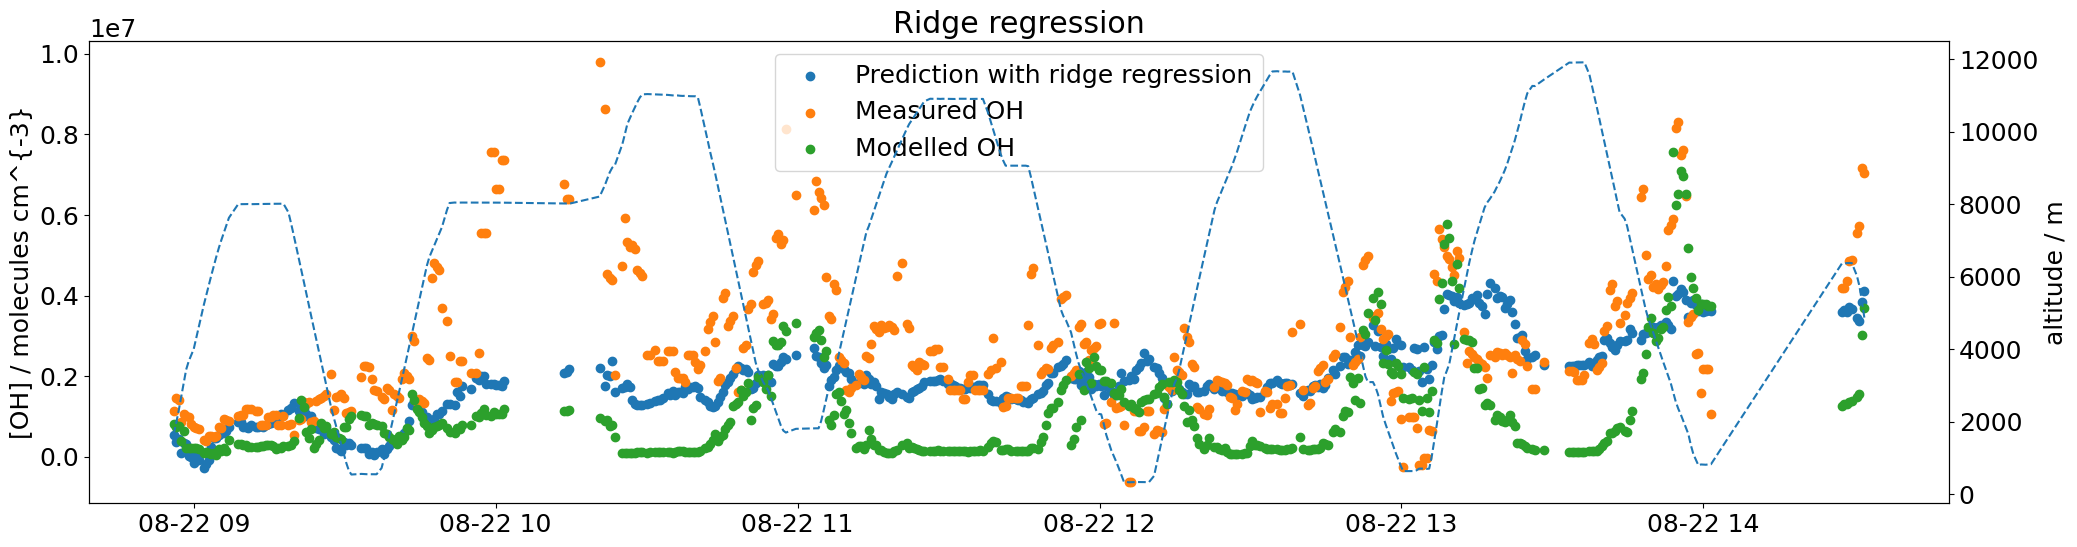

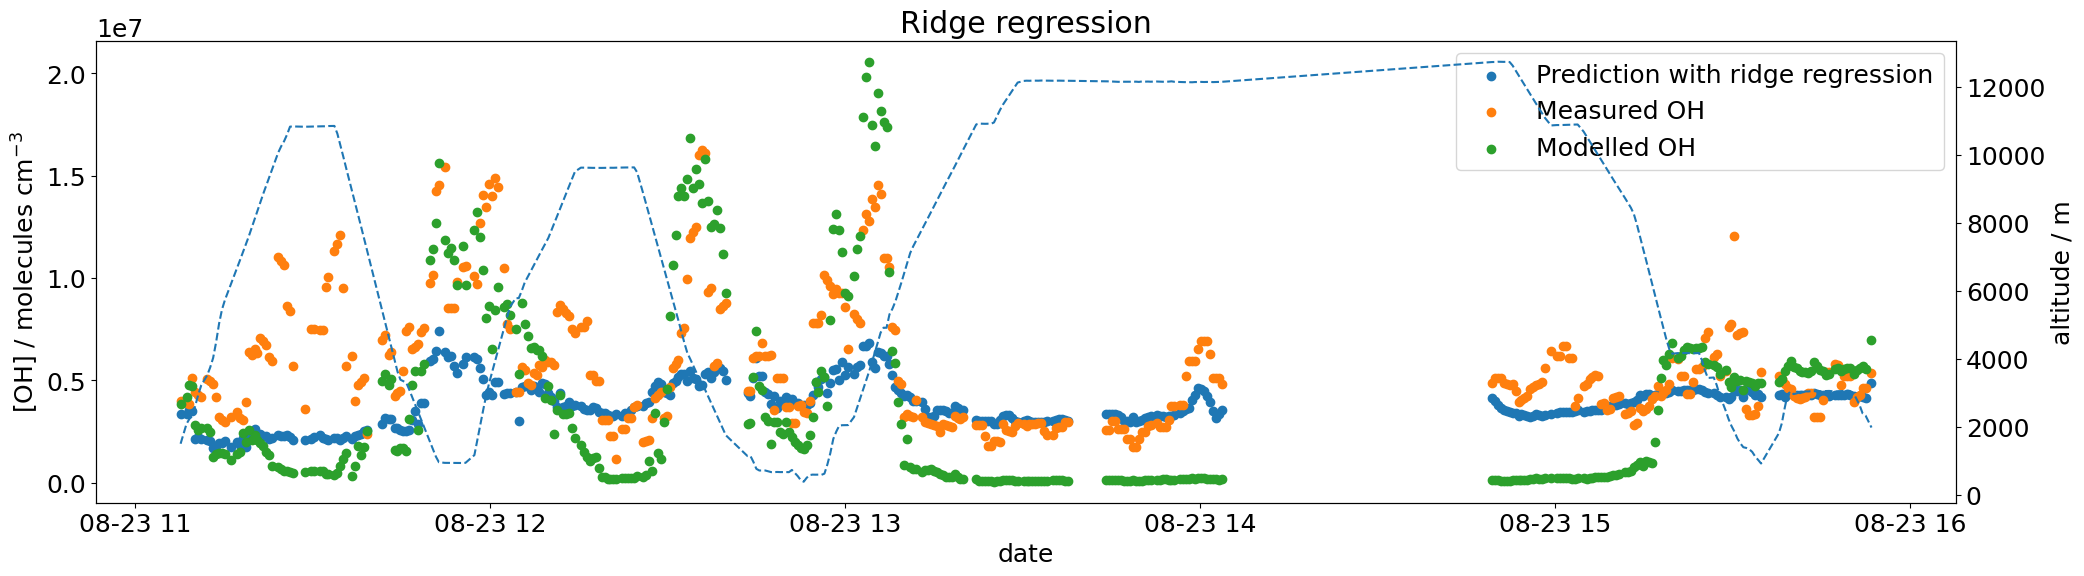

In [10]:
import sklearn
from sklearn.linear_model import Ridge

X = df_inputs   # 100 samples, 5 input features
y = df["[OH]_measured"]  # single output

# X_train = df_inputs[df["date"] > "2016-07-30"]
X_train_normalised = scaler.fit_transform(X_train)
# y_train = df[["[OH]_measured"]][df["date"] > "2016-07-30"]
y_train_normalised = scaler.fit_transform(y_train)

X_test = df_inputs[(df["date"] > "2016-08-22")]
X_test_normalised = scaler.fit_transform(X_test)
y_test = df[["[OH]_measured"]][(df["date"] > "2016-08-22")]
# y_test_normalised = scaler.transform(y_test)

ridgereg = Ridge()  # alpha controls the regularization strength
ridgereg.fit(X_train_normalised, y_train)

pred_ridgereg = ridgereg.predict(X_test_normalised)

ridgereg_HO2 = Ridge()  # alpha controls the regularization strength
ridgereg_HO2.fit(X_train_normalised_HO2, y_train)

pred_ridgereg_HO2 = ridgereg_HO2.predict(X_test_normalised_HO2)


print("Model score on training data:", ridgereg.score(X_train_normalised, y_train))
print("Model score on testing data:", ridgereg.score(X_test_normalised, y_test))

print("WITH HO2")

print("Model score on training data:", ridgereg_HO2.score(X_train_normalised_HO2, y_train))
print("Model score on testing data:", ridgereg_HO2.score(X_test_normalised_HO2, y_test))

fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_ylabel('[OH] / molecules cm^{-3}')
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], pred_ridgereg[0:indexes], label = "Prediction with ridge regression")
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], y_test[0:indexes], label = "Measured OH")
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], df["[OH]_calc"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], label = "Modelled OH")
ax1.legend(prop={'size':20})

ax2 = ax1.twinx()
ax2.set_ylabel('altitude / m')
ax2.plot(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], df["Altitude"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], linestyle='--', label = "Altitude")
# ax2.set_ylim(0, 13000)
ax1.legend()
ax2

plt.title("Ridge regression")


fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_xlabel('date')
ax1.set_ylabel('[OH] / molecules cm$^{-3}$')
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], pred_ridgereg[indexes:], label = "Prediction with ridge regression")
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], y_test[indexes:], label = "Measured OH")
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], df["[OH]_calc"][(df["date"] > "2016-08-23")], label = "Modelled OH")
ax1.legend(prop={'size':20})

ax2 = ax1.twinx()
ax2.set_ylabel('altitude / m')
ax2.plot(df["date"][(df["date"] > "2016-08-23")], df["Altitude"][(df["date"] > "2016-08-23")], linestyle='--', label = "Altitude")
# ax2.set_ylim(0, 13000)
ax1.legend()
ax2

plt.title("Ridge regression")

[0, 1000, 2000, 3000, 4000, 5000, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000, 10500, 11000, 11500, 12000, 12500]


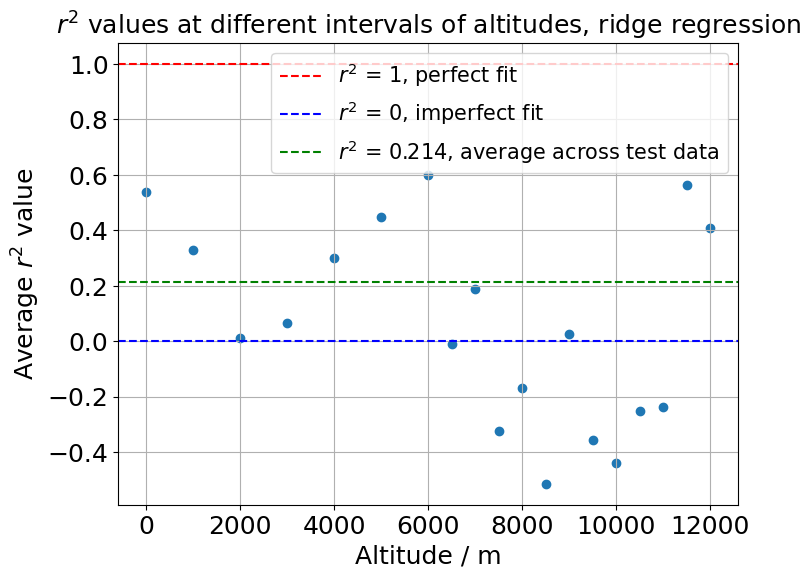

In [43]:
from sklearn.metrics import mean_squared_error
numbers = list(range(0, 6000, 1000))
numbers = numbers + (list(range(6000, 13000, 500)))
metrics_r2 = []
metrics_rmse = []
print(numbers)
for i in range(len(numbers) - 1):
    # print(numbers[i+1])
    X = X_test_normalised[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    y = y_test[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    # print("Model score for altitude:", sklearn.metrics.r2_score(X, y))
    metrics_r2.append(ridgereg.score(X, y))
    # metrics_rmse.append(np.sqrt(mean_squared_error(X_test, y_test)))
    # print(i)

fig, ax = plt.subplots(figsize = (8, 6))
plt.rcParams.update({'font.size':15})

plt.scatter(numbers[:-1], metrics_r2)
plt.axhline(y=1, color='r', linestyle='--', label='${r^2}$ = 1, perfect fit')
plt.axhline(y=0, color='b', linestyle='--', label='${r^2}$ = 0, imperfect fit')
plt.axhline(y = (ridgereg.score(X_test_normalised, y_test)), color = 'g', linestyle = '--', label = f'$r^2$ = {round(ridgereg.score(X_test_normalised, y_test), 3)}, average across test data')
plt.xlabel("Altitude / m")
plt.ylabel("Average $r^2$ value")
plt.title("$r^2$ values at different intervals of altitudes, ridge regression")
plt.legend(prop={'size':15})

plt.grid()

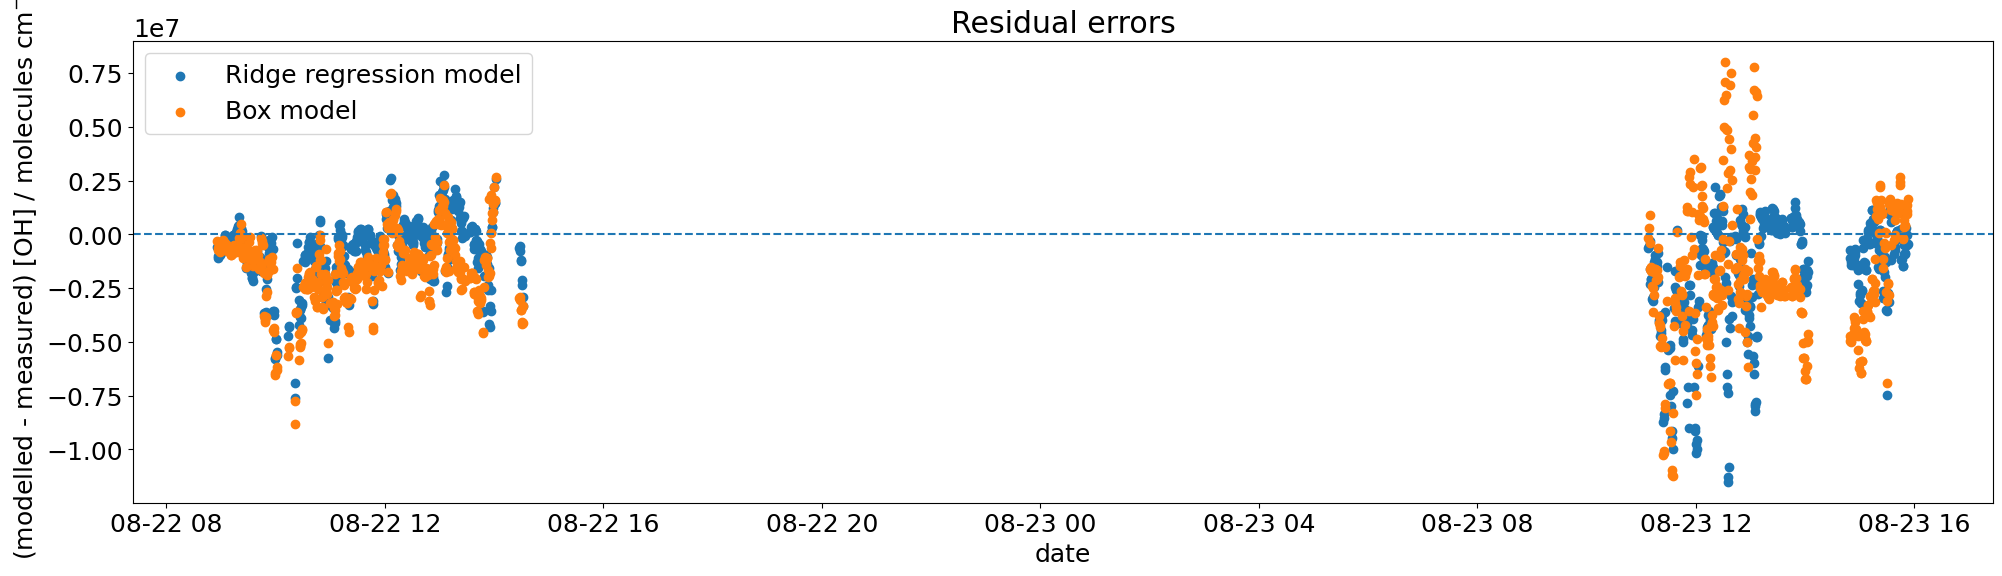

RMSE: 2478635.7118450864
RMSE with HO2: 2317596.4429209777


In [44]:
mpl.rcParams["font.size"] = 18

y_test = df["[OH]_measured"][(df["date"] > "2016-08-22")]

fig, ax1 = plt.subplots(figsize = (24, 6))
plt.scatter(df["date"][(df["date"] > "2016-08-22")], (ridgereg.predict(X_test_normalised) - y_test),label='Ridge regression model')
plt.scatter(df["date"][(df["date"] > "2016-08-22")], (df["[OH]_calc"][(df["date"] > "2016-08-22")] - y_test),label='Box model')


# plotting line for zero residual error
plt.axhline(y=0, linestyle = "--")

# plotting legend
plt.legend()

# plot title
plt.title("Residual errors")

plt.xlabel("date")
plt.ylabel("(modelled - measured) [OH] / molecules cm$^{-3}$")


# method call for showing the plot
plt.show()
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_ridgereg)))
print("RMSE with HO2:", np.sqrt(mean_squared_error(y_test, pred_ridgereg_HO2)))

### Gradient boosting
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html

This algorithm builds an additive model in a forward stage-wise fashion. It produces a predictive model from an ensemble of weak predictive models

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


Model score on training data: 0.8242194907591196
Model score on testing data: 0.26005730346466305
WITH HO2 AS TRAINING DATA
Model score on training data: 0.8336897056543149
Model score on testing data: 0.37875880053118705


Text(0.5, 1.0, 'Gradient boosting')

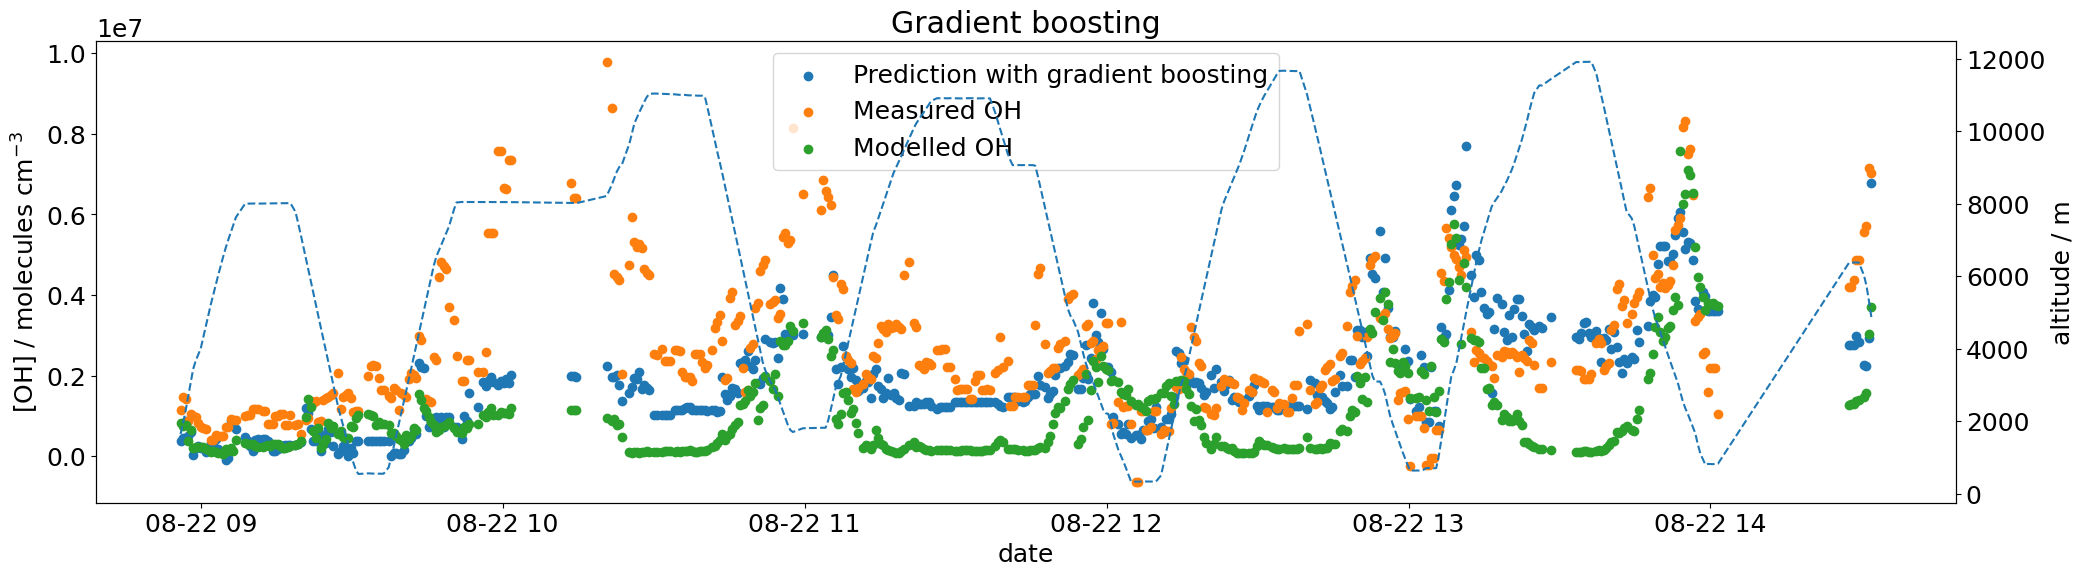

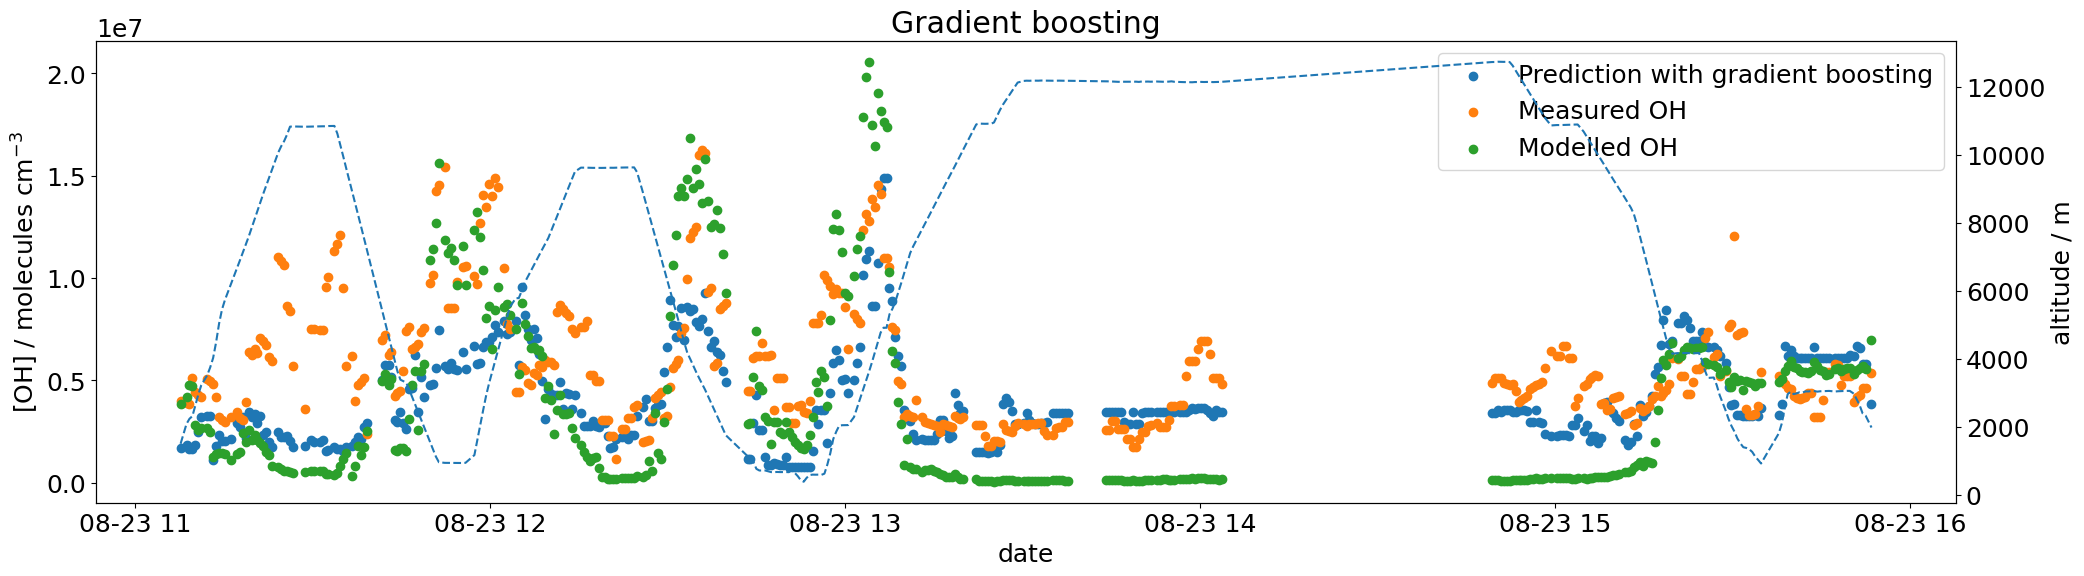

In [11]:
from sklearn.ensemble import GradientBoostingRegressor
# GBRT model
model = GradientBoostingRegressor()

model_HO2 = GradientBoostingRegressor()

# Train
model.fit(X_train_normalised, y_train)

model_HO2.fit(X_train_normalised_HO2, y_train)

y_pred = model.predict(X_test_normalised)

y_pred_HO2 = model_HO2.predict(X_test_normalised_HO2)

print(f"Model score on training data: {model.score(X_train_normalised, y_train)}")
print(f"Model score on testing data: {model.score(X_test_normalised, y_test)}")

print("WITH HO2 AS TRAINING DATA")

print(f"Model score on training data: {model_HO2.score(X_train_normalised_HO2, y_train)}")
print(f"Model score on testing data: {model_HO2.score(X_test_normalised_HO2, y_test)}")

import matplotlib as mpl
mpl.rcParams["font.size"] = 18


fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_xlabel('date')
ax1.set_ylabel('[OH] / molecules cm$^{-3}$')
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], y_pred[0:indexes], label = "Prediction with gradient boosting")
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], y_test[0:indexes], label = "Measured OH")
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], df["[OH]_calc"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], label = "Modelled OH")
ax1.legend(prop={'size':20})

ax2 = ax1.twinx()
ax2.set_ylabel('altitude / m')
ax2.plot(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], df["Altitude"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], linestyle='--', label = "Altitude")
# ax2.set_ylim(0, 13000)
ax1.legend()
ax2
plt.title("Gradient boosting")


fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_xlabel('date')
ax1.set_ylabel('[OH] / molecules cm$^{-3}$')
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], y_pred[indexes:], label = "Prediction with gradient boosting")
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], y_test[indexes:], label = "Measured OH")
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], df["[OH]_calc"][(df["date"] > "2016-08-23")], label = "Modelled OH")
ax1.legend(prop={'size':20})

ax2 = ax1.twinx()
ax2.set_ylabel('altitude / m')
ax2.plot(df["date"][(df["date"] > "2016-08-23")], df["Altitude"][(df["date"] > "2016-08-23")], linestyle='--', label = "Altitude")
# ax2.set_ylim(0, 13000)
ax1.legend()
ax2

plt.title("Gradient boosting")

[0, 1000, 2000, 3000, 4000, 5000, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000, 10500, 11000, 11500, 12000, 12500]


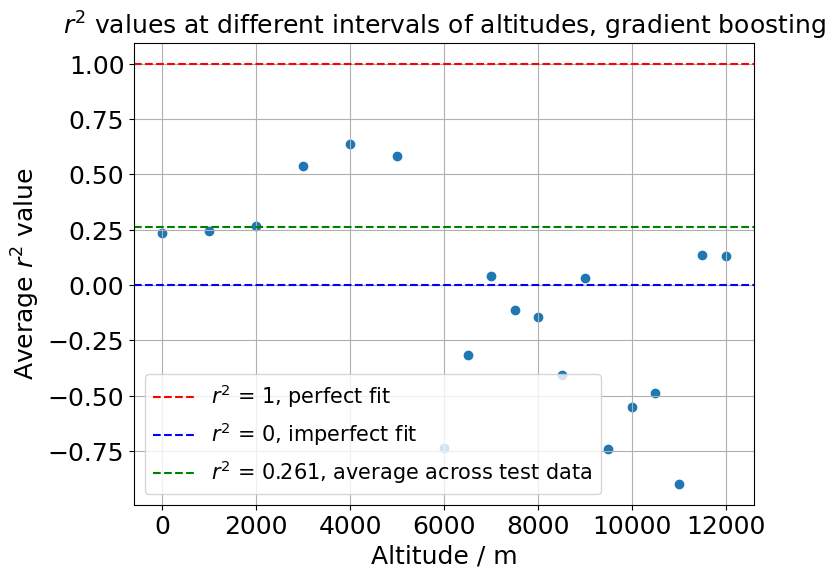

In [47]:
from sklearn.metrics import mean_squared_error
numbers = list(range(0, 6000, 1000))
numbers = numbers + (list(range(6000, 13000, 500)))
metrics_r2 = []
metrics_rmse = []
print(numbers)
for i in range(len(numbers) - 1):
    # print(numbers[i+1])
    X = X_test_normalised[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    y = y_test[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    # print("Model score for altitude:", sklearn.metrics.r2_score(X, y))
    metrics_r2.append(model.score(X, y))
    # metrics_rmse.append(np.sqrt(mean_squared_error(X_test, y_test)))
    # print(i)

fig, ax = plt.subplots(figsize = (8, 6))
plt.rcParams.update({'font.size':15})

plt.scatter(numbers[:-1], metrics_r2)
plt.axhline(y=1, color='r', linestyle='--', label='${r^2}$ = 1, perfect fit')
plt.axhline(y=0, color='b', linestyle='--', label='${r^2}$ = 0, imperfect fit')
plt.axhline(y = (model.score(X_test_normalised, y_test)), color = 'g', linestyle = '--', label = f'$r^2$ = {round(model.score(X_test_normalised, y_test), 3)}, average across test data')
plt.xlabel("Altitude / m")
plt.ylabel("Average $r^2$ value")
plt.title("$r^2$ values at different intervals of altitudes, gradient boosting")
plt.legend(prop={'size':15})

plt.grid()

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but GradientBoostingRegressor was fitted without feature names
  warnings.warn(


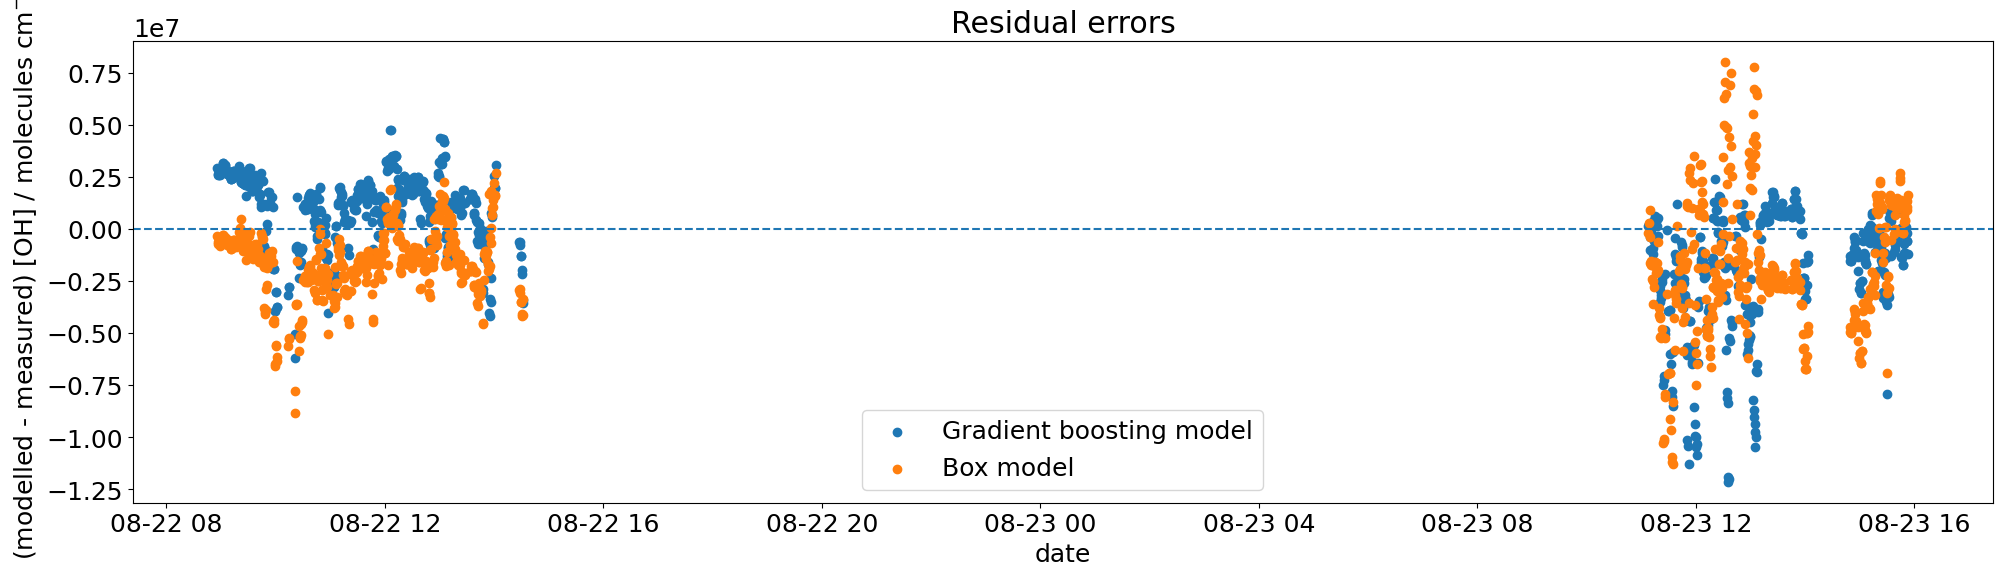

RMSE: 2403423.9102715305
RMSE with HO2: 2194421.7011614814


In [48]:
mpl.rcParams["font.size"] = 18

y_test = df["[OH]_measured"][(df["date"] > "2016-08-22")]

fig, ax1 = plt.subplots(figsize = (24, 6))
plt.scatter(df["date"][(df["date"] > "2016-08-22")], (model.predict(X_test) - y_test), label='Gradient boosting model')
plt.scatter(df["date"][(df["date"] > "2016-08-22")], (df["[OH]_calc"][(df["date"] > "2016-08-22")] - y_test),label='Box model')

# plotting line for zero residual error
plt.axhline(y=0, linestyle = "--")

# plotting legend
plt.legend()

# plot title
plt.title("Residual errors")

plt.xlabel("date")
plt.ylabel("(modelled - measured) [OH] / molecules cm$^{-3}$")

# method call for showing the plot
plt.show()

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

print("RMSE with HO2:", np.sqrt(mean_squared_error(y_test, y_pred_HO2)))

Text(0, 0.5, 'Feature')

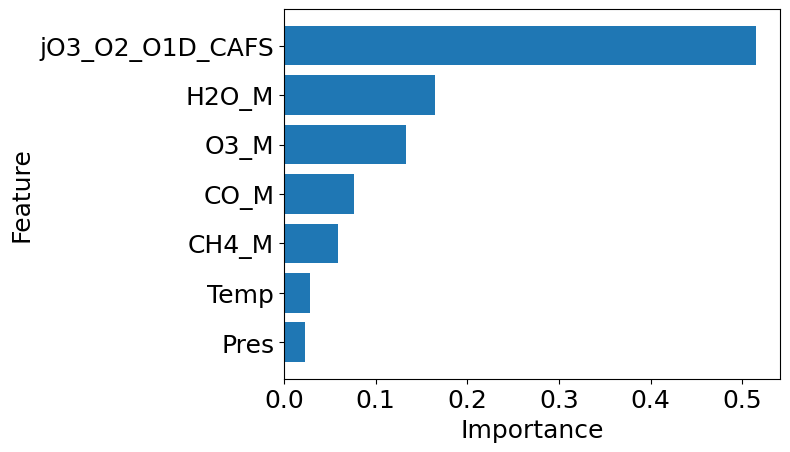

In [49]:
importances = model.feature_importances_

indices = np.argsort(importances)

fig, ax = plt.subplots()
ax.barh(range(len(importances)), importances[indices])
ax.set_yticks(range(len(importances)))
_ = ax.set_yticklabels(np.array(X_train.columns)[indices])
plt.xlabel("Importance")
plt.ylabel("Feature")